# Risultati, statistiche e performance di ItalianClassification

Per la valutazione viene usato lo stesso modello e lo stesso split di test registrato nei metadati del file `.joblib` prodotto da `scripts/training_lgbmclassifier.py`.

In questo modo la valutazione mostrata qui rimane coerente con `scripts/evaluate_model.py`: stessa soglia, stesso `test_csv`, stesso report testuale e stesse metriche finali.

## Caricamento del modello


In [1]:
import os
import sys

import joblib
import pandas as pd
from sklearn.inspection import permutation_importance

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.blocks.classifiers import QualityClassifier
# modello_di_prova o lgbm_quality_model
model_path = os.path.join(project_root, "models", "lgbm_quality_model.joblib")
artifact = joblib.load(model_path)
training_metadata = artifact.get("training_metadata", {})
threshold = artifact.get("threshold") or training_metadata.get("validation_threshold") or 0.65
test_csv = training_metadata.get("test_csv") or os.path.join(project_root, "data", "splits", "doc_stats_test.csv")

if not os.path.exists(test_csv):
    raise FileNotFoundError(f"Dataset di test non trovato: {test_csv}")

print("\nCaricamento modello...")
classifier = QualityClassifier(model_path=model_path, threshold=threshold)
print("Modello caricato con successo!")
print(f"Threshold in uso: {threshold}")
print(f"Test CSV in uso: {test_csv}")
if training_metadata:
    print("Split di training trovati nel modello:")
    print(f"   Source: {training_metadata.get('source_csv')}")
    print(f"   Train:  {training_metadata.get('train_csv')}")
    print(f"   Val:    {training_metadata.get('validation_csv')}")
    print(f"   Test:   {training_metadata.get('test_csv')}")
    # print(f"   Split_metadata:  {classifier.split_metadata}")


Caricamento modello...
Modello caricato con successo!
Threshold in uso: 0.65
Test CSV in uso: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Split di training trovati nel modello:
   Source: /home/stefano/ita-llm-pipeline/output/feature/doc_stats_per_file.csv
   Train:  /home/stefano/ita-llm-pipeline/data/splits/doc_stats_train.csv
   Val:    /home/stefano/ita-llm-pipeline/data/splits/doc_stats_val.csv
   Test:   /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv


## Valutazione tramite metriche ottenute in evaluation.py

Si mostrano le seguenti metriche:
+ L'accuratezza del modello è misurata come il rapporto tra le classificazioni corrette e la totalità delle classificazioni effettuate dal modello.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
+ $$Precision = \frac{TP}{TP + FP}$$
+ $$Recall = \frac{TP}{TP + FN}$$
+ $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [2]:
from src.blocks.evaluation import evaluate_model

print("\nValutazione in corso...")
result = evaluate_model(
    classifier=classifier,
    csv_path=test_csv,
    label_column="label",
    output_dir=None # oppure output_dir="evaluatione" se vuoi salvare
)
print("\nValutazione completata con successo!")

X, y, _ =classifier._load_labeled_dataset(
    csv_path=test_csv,
    feature_names=classifier.feature_names,
    label_column="label",
)
X_scaled = pd.DataFrame(
    classifier.scaler.transform(X),
    columns=classifier.feature_names,
    index=X.index,
)

model = classifier.model
feature_names = classifier.feature_names
cm = result["confusion_matrix"]
report_dict = result["classification_report"]


Valutazione in corso...

REPORT DI VALUTAZIONE DEL MODELLO
Dataset: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Modello: /home/stefano/ita-llm-pipeline/models/lgbm_quality_model.joblib
Soglia: 0.65
Timestamp: 2026-06-14 07:39:34

--------------------------------------------------------------------------------
METRICHE GLOBALI
--------------------------------------------------------------------------------
Accuracy:          0.9189 (91.89%)
Balanced Accuracy: 0.8813 (88.13%)
F1-Score:          0.8529
ROC-AUC:           0.9705

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted:Bad  Predicted:Good
Actual:Bad          2251              59
Actual:Good          208             774

Valutazione completata con successo!


## Calcolo e visualizzazione della Permutation Importance relative alle feature utilizzate

L'importance è la metrica che misura quanto la realtiva feature contribuisce alla capacità del modello di predire, quindi misura quanto la feature è utile alla costruzione degli alberi decisionali nel nostro caso. Tramite questa metrica si identificano le feature che guidano maggiormente le predizioni del modello. 

Di seguito vengono mostrate le prime 10 feature per importanza del modello utilizzato nel progetto. 

In [3]:
perm = permutation_importance(
    classifier.model,
    X_scaled,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": classifier.feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)
    
print("\n" + "=" * 80)
print("TOP 10 FEATURES (Feature Importance)")
print("-" * 80)
for _, row in importance_df.head(10).iterrows():
    importance_pct = (row["importance_mean"] / importance_df["importance_mean"].sum()) * 100
    bar_length = int(importance_pct / 2)
    bar = "█" * bar_length
    print(f"{row['feature']:30s} {bar:40s} {importance_pct:6.2f}% "
          f"(±{row['importance_std']:.4f})")
print("\n" + "=" * 80)


TOP 10 FEATURES (Feature Importance)
--------------------------------------------------------------------------------
avg_line_length                ██████████████                            29.22% (±0.0049)
stopword_ratio                 █████████                                 18.94% (±0.0054)
language_score                 ███                                        6.47% (±0.0038)
avg_word_length                ██                                         4.15% (±0.0013)
exclamation_ratio              ██                                         4.15% (±0.0026)
consonant_ratio                █                                          3.29% (±0.0025)
white_space_ratio              █                                          2.97% (±0.0019)
line_count                     █                                          2.84% (±0.0023)
parenthesis_ratio              █                                          2.75% (±0.0016)
digit_ratio                    █                                       

## Confusion Matrix

Nella matrice di confusione vengono mostrati tutti i campioni `Positive` sulla prima riga della matrice e tutti i campioni `Negative` sulla seconda riga. Questi vengono divisi come: `TP` (True Positive) in posizione (0,0), `FP` (False Positive) in posizione (0,1), `FN` in posizione (1,0), `TN` in posizione (1,1).

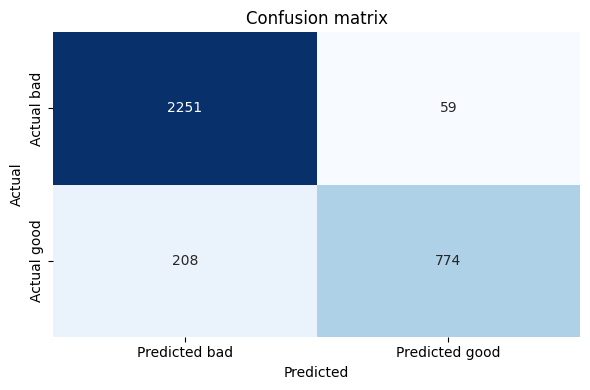

In [4]:
import seaborn as sns

cm_df = pd.DataFrame(
    cm,
    index=["Actual bad", "Actual good"],
    columns=["Predicted bad", "Predicted good"],
)
# print("\n\tConfusion matrix")
# display(cm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Metriche Dettagliate per Classe

Questo report mostra le metriche di classificazione calcolate **separatamente per ogni classe** ("bad" e "good"). 

Le metriche per classe sono ottenute usando scikit-learn's `classification_report()`, che automaticamente:
1. **Calcula True Positives (TP)**: numero di predizioni corrette per quella classe
2. **Calcula False Positives (FP)**: numero di campioni di altre classi predetti erroneamente come questa classe
3. **Calcula False Negatives (FN)**: numero di campioni di questa classe predetti erroneamente come altre classi

A partire da TP, FP, FN, calcola:
- **Precision**: $\text{Precision} = \frac{TP}{TP + FP}$ (accuratezza dei positivi predetti)
- **Recall**: $\text{Recall} = \frac{TP}{TP + FN}$ (copertura dei positivi reali)
- **F1-Score**: $\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ (media armonica)

**Support** indica quanti campioni di quella classe sono presenti nel dataset di test.

In [5]:
import pandas as pd
import numpy as np

# Estrai le metriche per classe dal report
bad_metrics = report_dict["bad"]
good_metrics = report_dict["good"]

# Crea un DataFrame per visualizzazione
metrics_df = pd.DataFrame({
    "Class": ["bad (scadenti)", "good (validi)"],
    "Precision": [f"{bad_metrics['precision']:.4f} ({bad_metrics['precision']*100:.2f}%)", 
                  f"{good_metrics['precision']:.4f} ({good_metrics['precision']*100:.2f}%)"],
    "Recall": [f"{bad_metrics['recall']:.4f} ({bad_metrics['recall']*100:.2f}%)", 
               f"{good_metrics['recall']:.4f} ({good_metrics['recall']*100:.2f}%)"],
    "F1-Score": [f"{bad_metrics['f1-score']:.4f}", 
                 f"{good_metrics['f1-score']:.4f}"],
    "Support": [f"{int(bad_metrics['support'])}", 
                f"{int(good_metrics['support'])}"]
})

print("\n" + "="*80)
print("METRICHE DETTAGLIATE PER CLASSE (Threshold = {})".format(threshold))
print("="*80 + "\n")
display(metrics_df)

# Metriche complessive
print("\n" + "="*80)
print("METRICHE COMPLESSIVE")
print("="*80)
print(f"\nAccuracy:              {result.get('accuracy', 'N/A'):.4f}")
print(f"Balanced Accuracy:     {result.get('balanced_accuracy', 'N/A'):.4f}")
print(f"ROC-AUC:               {result.get('roc_auc', 'N/A'):.4f}")
print(f"F1-Score (weighted):   {result.get('f1_score', 'N/A'):.4f}")

print(f"\n{'─'*80}")
print("MATRICE DI CONFUSIONE (in numeri assoluti)")
print(f"{'─'*80}")
print(f"\nDocumenti SCADENTI (label='bad'):")
print(f"  - Classificati CORRETTAMENTE come scadenti:      {cm[0][0]:4d} (True Positives)")
print(f"  - Classificati ERRONEAMENTE come validi:        {cm[0][1]:4d} (False Negatives)")
print(f"\nDocumenti VALIDI (label='good'):")
print(f"  - Classificati ERRONEAMENTE come scadenti:      {cm[1][0]:4d} (False Positives)")
print(f"  - Classificati CORRETTAMENTE come validi:       {cm[1][1]:4d} (True Positives)")

# Interpretazione
print(f"\n{'─'*80}")
print("INTERPRETAZIONE")
print(f"{'─'*80}")
print(f"\nIl modello cattura il {bad_metrics['recall']*100:.1f}% dei documenti scadenti (recall su 'bad')")
print(f"Quando dice che un documento è BUONO, ha il {good_metrics['precision']*100:.1f}% di probabilità di aver ragione")
print(f"Il modello cattura solo il {good_metrics['recall']*100:.1f}% dei documenti validi (recall su 'good')")
print(f"  → Ciò significa che {int(cm[1][0])} documenti validi vengono erroneamente scartati")


METRICHE DETTAGLIATE PER CLASSE (Threshold = 0.65)



,Class,Precision,Recall,F1-Score,Support
0,bad (scadenti),0.9154 (91.54%),0.9745 (97.45%),0.9440,2310
1,good (validi),0.9292 (92.92%),0.7882 (78.82%),0.8529,982



METRICHE COMPLESSIVE

Accuracy:              0.9189
Balanced Accuracy:     0.8813
ROC-AUC:               0.9705
F1-Score (weighted):   0.8529

────────────────────────────────────────────────────────────────────────────────
MATRICE DI CONFUSIONE (in numeri assoluti)
────────────────────────────────────────────────────────────────────────────────

Documenti SCADENTI (label='bad'):
  - Classificati CORRETTAMENTE come scadenti:      2251 (True Positives)
  - Classificati ERRONEAMENTE come validi:          59 (False Negatives)

Documenti VALIDI (label='good'):
  - Classificati ERRONEAMENTE come scadenti:       208 (False Positives)
  - Classificati CORRETTAMENTE come validi:        774 (True Positives)

────────────────────────────────────────────────────────────────────────────────
INTERPRETAZIONE
────────────────────────────────────────────────────────────────────────────────

Il modello cattura il 97.4% dei documenti scadenti (recall su 'bad')
Quando dice che un documento è BUONO, ha i

## Correlation Matrix

La figura mostra la matrice di correlazione di Pearson calcolata sulle feature estratte dal dataset per l'addestramento del classificatore LightGBM. Questa visualizzazione è fondamentale per identificare la presenza di multicollinearità e comprendere le relazioni lineari tra le diverse metriche testuali.

+ Il rosso scuro indica una forte correlazione positiva ($+1$): al crescere di una variabile, l'altra cresce in modo lineare.
+ Il blu scuro indica una forte correlazione negativa ($-1$): al crescere di una variabile, l'altra decresce in modo lineare.
+ Il grigio/azzurro chiaro indica l'assenza di correlazione lineare significativa ($\approx 0$)

Osservazioni sul grafico:

+ Gruppi ad alta correlazione positiva (blocchi rossi): Si nota una forte correlazione positiva tra feature di conteggio come word_count, sentence_count, vocabulary_size, line_count e avg_paragraph_length. Questo è un comportamento atteso, poiché testi più lunghi tendono ad avere un numero maggiore di parole, frasi e vocaboli unici.

+ Interazioni negative (blocchi blu): Esistono relazioni inversamente proporzionali evidenti, come quella tra digit_ratio / non_alpha_digit_ratio e alcune metriche basate puramente su parole o vocali (vowel_ratio), indicando contesti di testo nettamente separati (es. testi discorsivi vs. testi ricchi di dati numerici o codice).

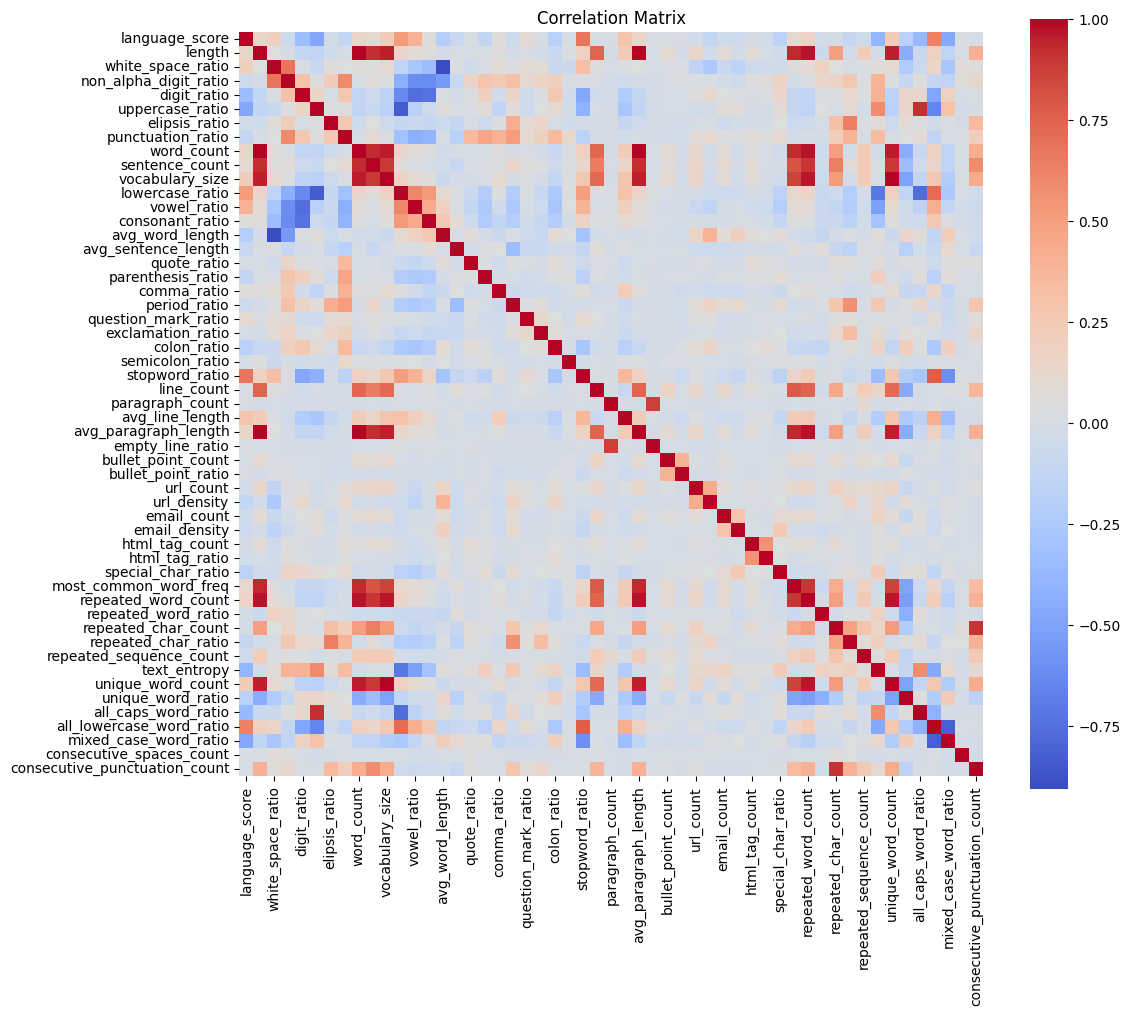

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Cross-validation del Modello Salvato

Valutazione del **modello salvato** su diversi fold del test set usando StratifiedKFold. Il modello NON viene ri-addestruito, solo valutato su diverse partizioni dei dati di test per misurare la stabilità delle metriche.

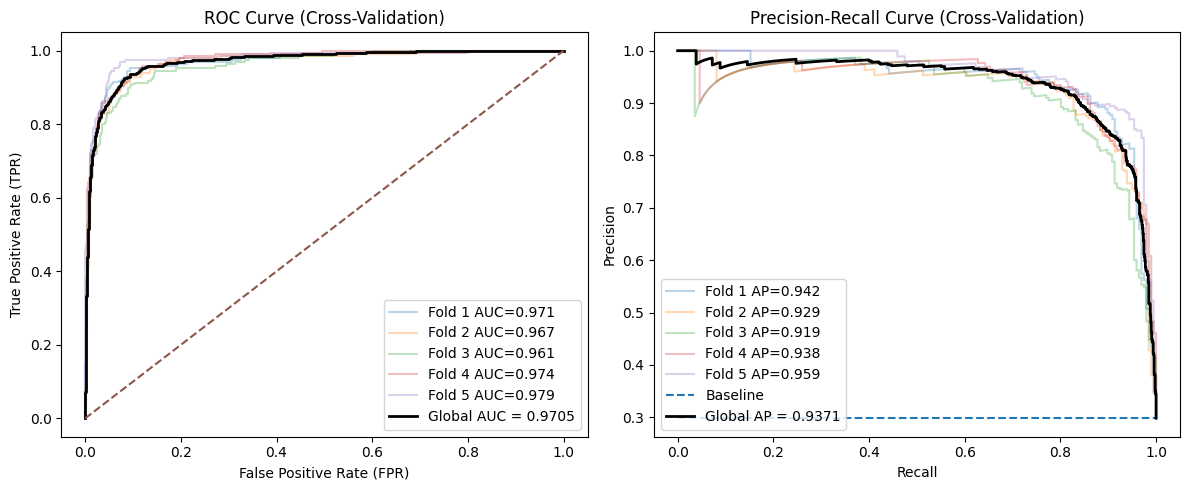

In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import ( 
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
# ===== INPUT =====
# model: (es. LGBM)
# X, y: dataset

# ===== SETUP =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# per aggregare risultati
y_true_all = []
y_scores_all = []

# per visualizzare fold singoli
plt.figure(figsize=(12, 5))

# ===== CROSS VALIDATION DEL MODELLO SALVATO =====
# Il modello NON viene ri-addestruito, solo valutato su diverse partizioni
saved_model = classifier.model  # Usa il modello salvato

for i, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # Non usiamo train_idx (non ri-addestriamo), solo val_idx per valutare
    X_val = X_scaled.iloc[val_idx]
    y_val = y.iloc[val_idx]

    # Valuta il modello salvato (senza ri-addestrare)
    y_scores = saved_model.predict_proba(X_val)[:, 1]

    # salva per aggregazione globale
    y_true_all.extend(y_val)
    y_scores_all.extend(y_scores)

    # ROC fold
    fpr, tpr, _ = roc_curve(y_val, y_scores)
    roc_auc = roc_auc_score(y_val, y_scores)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i+1} AUC={roc_auc:.3f}")

    # PR fold
    precision, recall, _ = precision_recall_curve(y_val, y_scores)
    pr_auc = average_precision_score(y_val, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, alpha=0.3, label=f"Fold {i+1} AP={pr_auc:.3f}")


# ===== METRICHE GLOBALI =====
y_true_all = np.array(y_true_all)
y_scores_all = np.array(y_scores_all)

# ROC globale
fpr, tpr, _ = roc_curve(y_true_all, y_scores_all)
roc_auc = roc_auc_score(y_true_all, y_scores_all)

# PR globale
precision, recall, _ = precision_recall_curve(y_true_all, y_scores_all)
pr_auc = average_precision_score(y_true_all, y_scores_all)

# ===== PLOT FINALE =====

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color="black", linewidth=2, label=f"Global AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Cross-Validation)")
plt.legend()

# PR
plt.subplot(1, 2, 2)
baseline = np.mean(y_true_all)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")

plt.plot(recall, precision, color="black", linewidth=2, label=f"Global AP = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Cross-Validation)")
plt.legend()

plt.tight_layout()
plt.show()

## Confronto curve ROC-AUC e PR-AUC dei modello LGBM e LogisticRegression

Mostro la validità della scelta di LGBM. LGBM è migliore di un baseline semplice come un modello lineare basato su LogisticRegression.

$$ Miglioramento (\%) = \frac{(LGBM\_AUC - LR\_AUC)}{LR\_AUC} \cdot 100  $$
$$ Miglioramento Assoluto (Δ) = LGBM\_AUC - LR\_AUC$$
$$ Rapporto = \frac{LGBM\_AUC}{LR\_AUC}$$

Dal Rapporto si deduce che LGBM è 1.0375x migliore di LogisticRegression



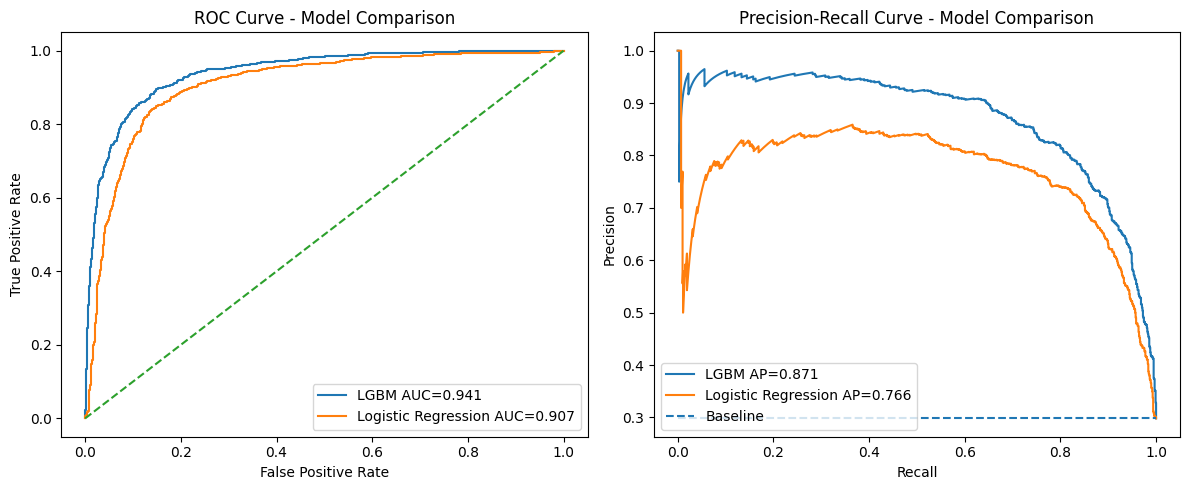

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# ===== MODELLI =====
models = {
    "LGBM": lgb.LGBMClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs')
}

plt.figure(figsize=(12, 5))

# ===== LOOP MODELLI =====
for i, (name, model) in enumerate(models.items()):    
    # predizioni out-of-fold (usa X_scaled per convergenza)
    y_scores = cross_val_predict(
        model,
        X_scaled,
        y,
        cv=5,
        method="predict_proba"
    )[:, 1]

    y_true = y

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"{name} AP={pr_auc:.3f}")


# ===== BASELINE PR =====
baseline = np.mean(y)
plt.subplot(1, 2, 2)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")

# ===== FINISH PLOT =====

# ROC
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()

# PR
plt.subplot(1, 2, 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()


## Analisi dei Miglioramenti: LGBM vs Baseline (LogisticRegression)

Di seguito quantifico i miglioramenti ottenuti utilizzando LGBM rispetto alla baseline considerata utilizzando la LogisticRegression.

In [9]:
# I valori sono già stati calcolati nella cella precedente

# Ricalcoliamo per avere i valori
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

models_comparison = {
    "LGBM": lgb.LGBMClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
}

results_dict = {}

for model_name, model in models_comparison.items():
    y_scores = cross_val_predict(model, X_scaled, y, cv=5, method="predict_proba")[:, 1]

    roc_auc = roc_auc_score(y, y_scores)
    ap = average_precision_score(y, y_scores)
    
    results_dict[model_name] = {"ROC-AUC": roc_auc, "AP": ap}
    
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Average Precision: {ap:.4f}")


# Calcolo i miglioramenti
lgbm_auc = results_dict["LGBM"]["ROC-AUC"]
lr_auc = results_dict["LogisticRegression"]["ROC-AUC"]
lgbm_ap = results_dict["LGBM"]["AP"]
lr_ap = results_dict["LogisticRegression"]["AP"]

auc_improvement_abs = lgbm_auc - lr_auc
auc_improvement_rel = (auc_improvement_abs / lr_auc) * 100
auc_improvement_ratio = lgbm_auc / lr_auc

ap_improvement_abs = lgbm_ap - lr_ap
ap_improvement_rel = (ap_improvement_abs / lr_ap) * 100
ap_improvement_ratio = lgbm_ap / lr_ap

print("\n\t\tMIGLIORAMENTI OTTENUTI CON LGBM")

print(f"\nROC-AUC:")
print(f"   Miglioramento assoluto: {auc_improvement_abs:+.4f}")
print(f"   Miglioramento relativo: {auc_improvement_rel:+.2f}%")
print(f"   Rapporto: LGBM è {auc_improvement_ratio:.3f}x migliore")

print(f"\nAverage Precision (AP):")
print(f"   Miglioramento assoluto: {ap_improvement_abs:+.4f}")
print(f"   Miglioramento relativo: {ap_improvement_rel:+.2f}%")
print(f"   Rapporto: LGBM è {ap_improvement_ratio:.3f}x migliore")


LGBM:
  ROC-AUC: 0.9406
  Average Precision: 0.8714

LogisticRegression:
  ROC-AUC: 0.9072
  Average Precision: 0.7659

		MIGLIORAMENTI OTTENUTI CON LGBM

ROC-AUC:
   Miglioramento assoluto: +0.0334
   Miglioramento relativo: +3.69%
   Rapporto: LGBM è 1.037x migliore

Average Precision (AP):
   Miglioramento assoluto: +0.1055
   Miglioramento relativo: +13.78%
   Rapporto: LGBM è 1.138x migliore


# Testing data-leakage
### Test del Dataset utilizzato

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

y_shuffled = np.random.permutation(y)

# Usa X_scaled per coerenza (come nel resto del notebook)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_shuffled, test_size=0.2, stratify=y_shuffled, random_state=42
)

# Addestro il modello e valuto la data-leakage dovuta da esso
# model.fit(X_train, y_train)
# y_scores = model.predict_proba(X_val)[:, 1]

# Usa il modello salvato per testare il dataset
# Se riesce a prevedere label casuali, il problema è nel dataset (data leakage)
saved_model = classifier.model
y_scores = saved_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_scores)
print(f"ROC-AUC del modello salvato con label casuali: {roc_auc:.4f}")
if roc_auc < 0.55:
    print(f"\nBUONO: ROC-AUC circa uguale a 0.5 indica che il dataset non causa data leakage")
    print(f"       Il modello, infatti, non riesce a prevedere etichette casuali")
else:
    print(f"ATTENZIONE: ROC-AUC = {roc_auc:.4f} è alto!")
    print(f"            Potrebbe esserci data leakage nel dataset")


ROC-AUC del modello salvato con label casuali: 0.4916

BUONO: ROC-AUC circa uguale a 0.5 indica che il dataset non causa data leakage
       Il modello, infatti, non riesce a prevedere etichette casuali


### Testing del Modello: Verifica di Data-Leakage Interno

Test per verificare se il **modello stesso** ha problemi di data-leakage interni (es. overfitting eccessivo su caratteristiche spurie). Addestriamo un nuovo modello su dati con label casuali: se riesce a prevedere comunque bene, il modello ha un problema.

**Nota**: Per una classificazione binaria (2 classi), ROC-AUC = 0.5 rappresenta una previsione completamente casuale (50% di probabilità per ogni classe).

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

y_shuffled = np.random.permutation(y)

# Usa X_scaled per coerenza
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_shuffled, test_size=0.2, stratify=y_shuffled, random_state=42
)

# Addestra un NUOVO modello su label casuali
# Se riesce a imparare comunque, il modello ha problemi interni
test_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
test_model.fit(X_train, y_train)
y_scores = test_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_scores)
print(f"ROC-AUC di un modello addestrato su label casuali: {roc_auc:.4f}")

if roc_auc < 0.55:
    print(f"\nBUONO: ROC-AUC ≈ 0.5")
    print(f"  Un modello addestrato su label casuali non riesce a fare previsioni")
    print(f"  Il modello non ha problemi interni di data-leakage")
else:
    print(f"\nATTENZIONE: ROC-AUC = {roc_auc:.4f} alto!")
    print(f"  Un modello addestrato su label casuali riesce a prevedere comunque")
    print(f"  Potrebbe esserci un problema nel processo di addestramento")

ROC-AUC di un modello addestrato su label casuali: 0.5045

BUONO: ROC-AUC ≈ 0.5
  Un modello addestrato su label casuali non riesce a fare previsioni
  Il modello non ha problemi interni di data-leakage


## Summary Plot of the features

/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


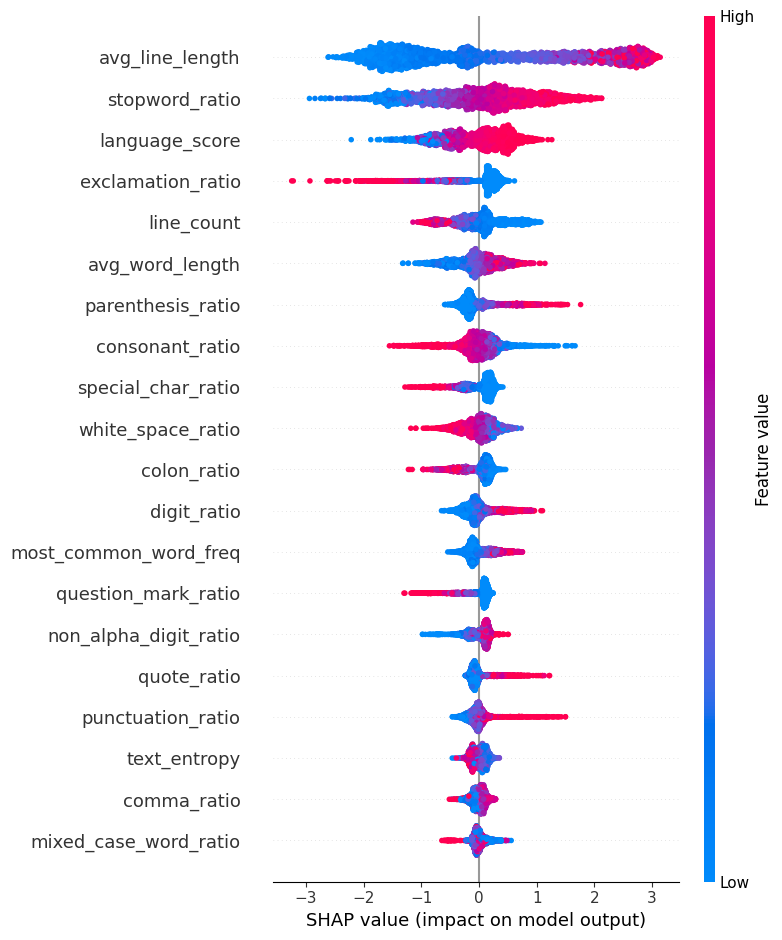

In [12]:
import shap

# model = modello LGBM già addestrato
model = classifier.model
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled)
shap_values_good = shap_values[1]
shap_values_bad = shap_values[0]

shap.summary_plot(shap_values, X_scaled)


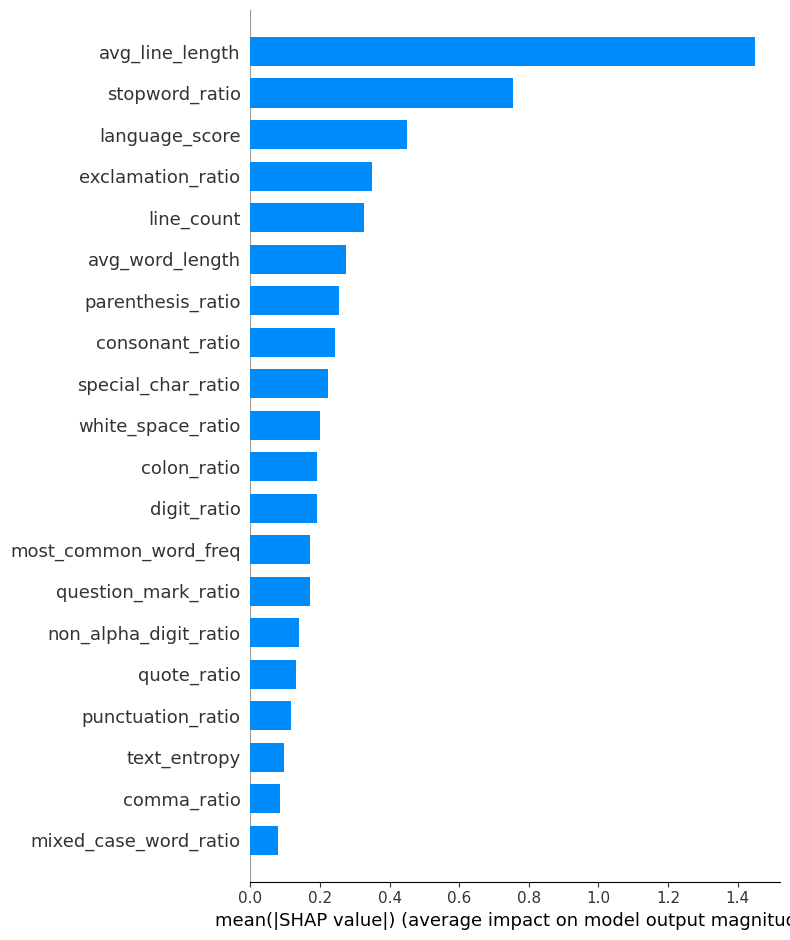

In [13]:
shap.summary_plot(shap_values, X_scaled, plot_type="bar")